# Pokémon Team Builder — v2
**Image Classification & 6th Member Recommendation**

Improvements over v1:
- **Stratified split** — each class is proportionally represented in train / val / test
- **Early stopping** — Phase 2 stops when val accuracy plateaus (patience = 7 epochs)

| Step | Section | Description |
|------|---------|-------------|
| 1 | EDA | Explore the dataset — class balance, image sizes, samples |
| 2 | Data Preparation | Train / val / test split, transforms, dataloaders |
| 3 | Model Training | EfficientNet-B0 fine-tuned with transfer learning |
| 4 | Evaluation | Top-1 / Top-5 accuracy, per-class accuracy, sample predictions |
| 5 | Recommendation | Given a team of 5, recommend the best 6th member |

## 0. Setup

In [1]:
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
DATA_DIR   = Path('PokemonData')
MODEL_PATH = Path('best_model_v2.pth')

IMG_SIZE         = 224
BATCH_SIZE       = 32
NUM_EPOCHS_HEAD  = 5    # Phase 1 — classifier head only
NUM_EPOCHS_FULL  = 20   # Phase 2 — max epochs (early stopping may trigger earlier)
LR_HEAD          = 1e-3
LR_FULL          = 1e-4
PATIENCE         = 7    # Phase 2 early stopping patience

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.gif', '.bmp', '.webp'}

def list_images(folder):
    """Return only valid image files, ignoring SVG and other non-PIL formats."""
    return [p for p in Path(folder).iterdir() if p.suffix.lower() in IMG_EXTS]

---
## 1. Exploratory Data Analysis

In [3]:
# Load class names from folder structure
class_names = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(class_names)
idx_to_class = {i: name for i, name in enumerate(class_names)}

print(f'Number of Pokemon (classes): {NUM_CLASSES}')
print(f'First 10: {class_names[:10]}')

Number of Pokemon (classes): 150
First 10: ['Abra', 'Aerodactyl', 'Alakazam', 'Alolan Sandslash', 'Arbok', 'Arcanine', 'Articuno', 'Beedrill', 'Bellsprout', 'Blastoise']


In [4]:
# Count images per class
counts = {cls: len(list_images(DATA_DIR / cls)) for cls in class_names}
vals = list(counts.values())

print(f'Total images  : {sum(vals):,}')
print(f'Mean per class: {np.mean(vals):.1f}')
print(f'Min per class : {min(vals):3d}  ({min(counts, key=counts.get)})')
print(f'Max per class : {max(vals):3d}  ({max(counts, key=counts.get)})')

Total images  : 6,820
Mean per class: 45.5
Min per class :  26  (Alakazam)
Max per class :  66  (Venusaur)


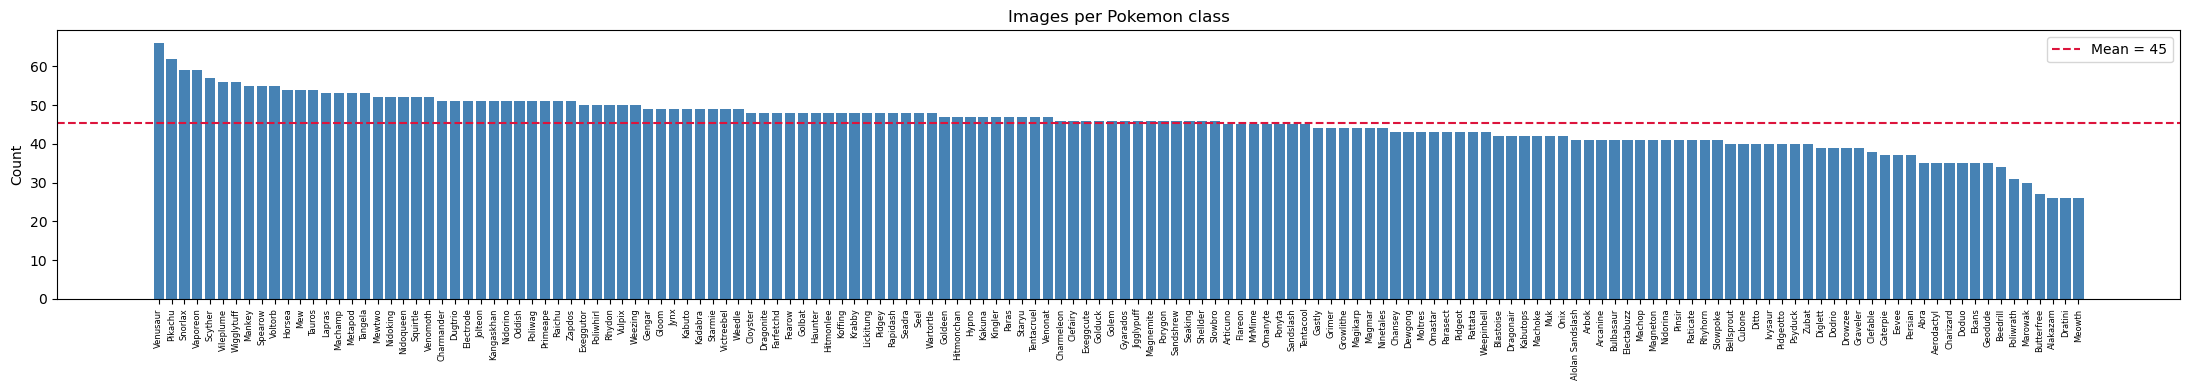

In [5]:
# Class distribution plot
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
names, sorted_vals = zip(*sorted_counts)

fig, ax = plt.subplots(figsize=(22, 4))
ax.bar(range(len(names)), sorted_vals, color='steelblue', edgecolor='none')
ax.axhline(np.mean(sorted_vals), color='crimson', linestyle='--',
           label=f'Mean = {np.mean(sorted_vals):.0f}')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=90, fontsize=6)
ax.set_title('Images per Pokemon class')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

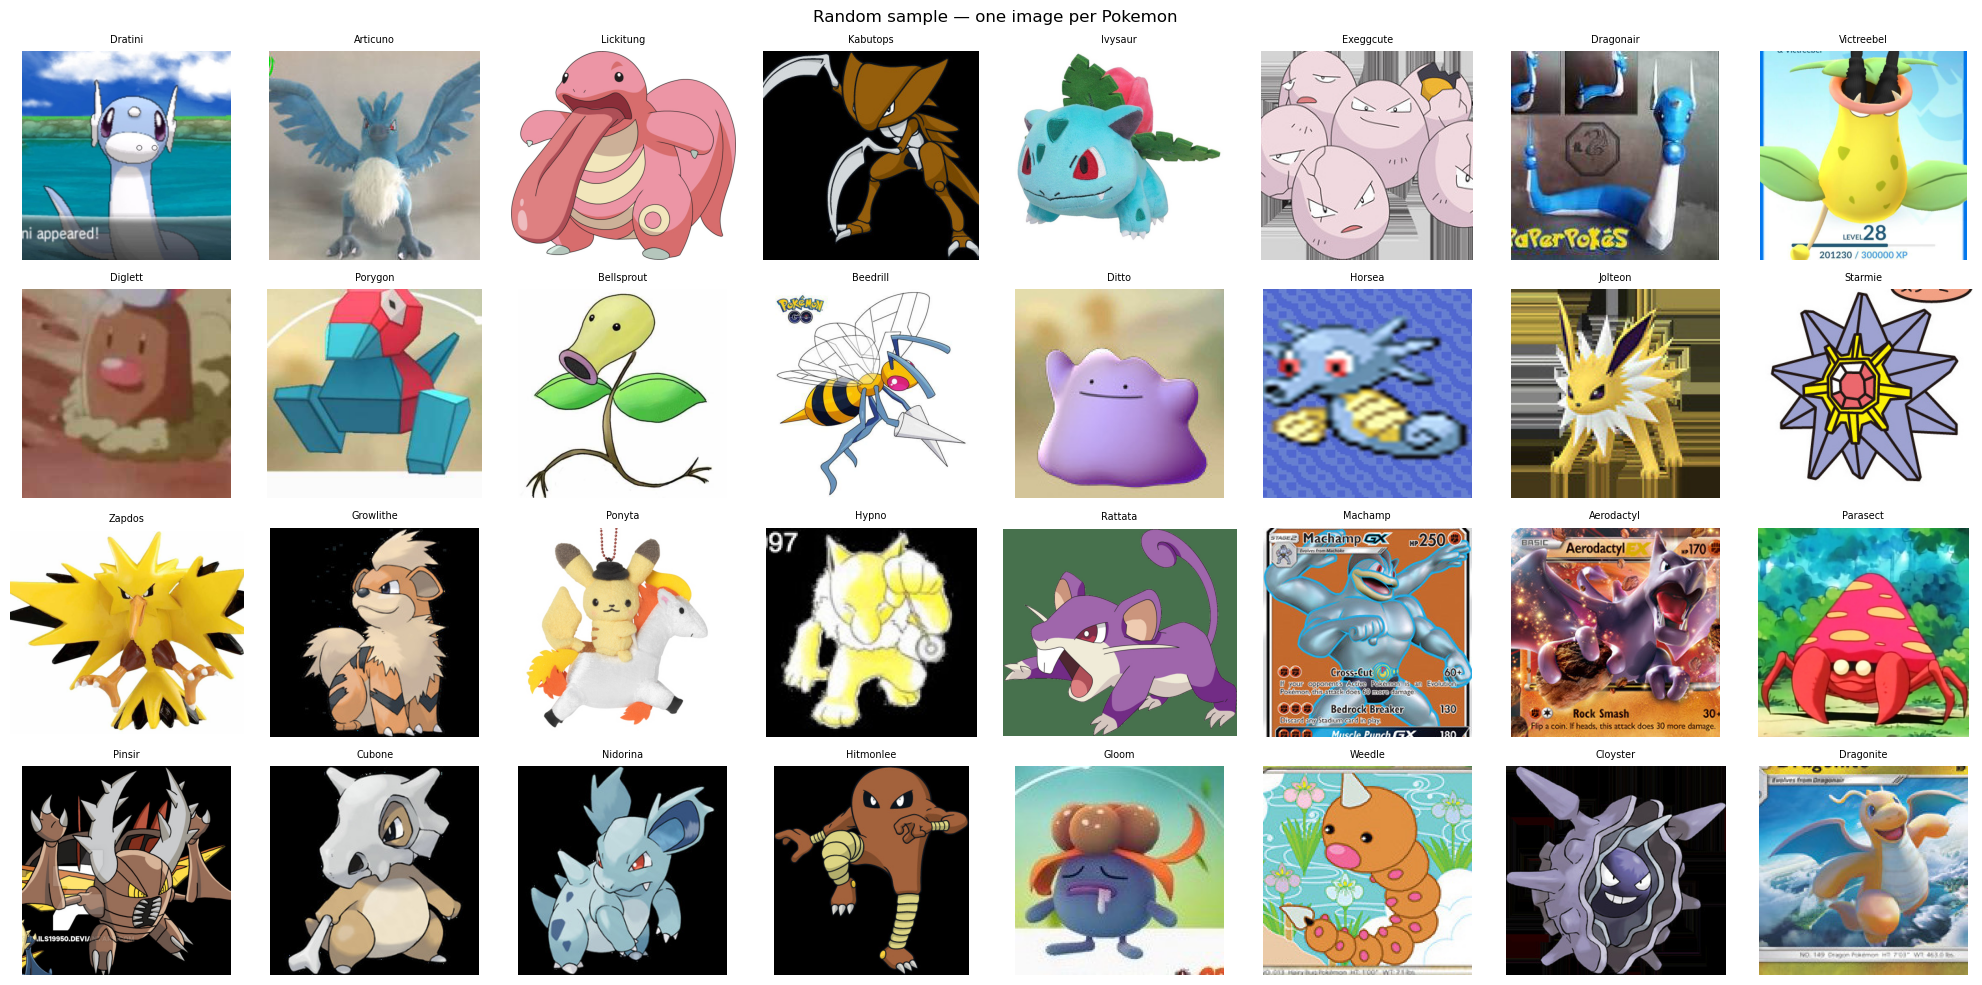

In [6]:
# Sample images — one random image per class (32 classes shown)
sample_classes = random.sample(class_names, 32)

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
for ax, cls in zip(axes.flat, sample_classes):
    imgs = list_images(DATA_DIR / cls)
    img  = Image.open(random.choice(imgs)).convert('RGB')
    ax.imshow(img)
    ax.set_title(cls, fontsize=7)
    ax.axis('off')
plt.suptitle('Random sample — one image per Pokemon', fontsize=12)
plt.tight_layout()
plt.show()

Width  — mean: 448  min: 54  max: 2348
Height — mean: 445  min: 54  max: 2348


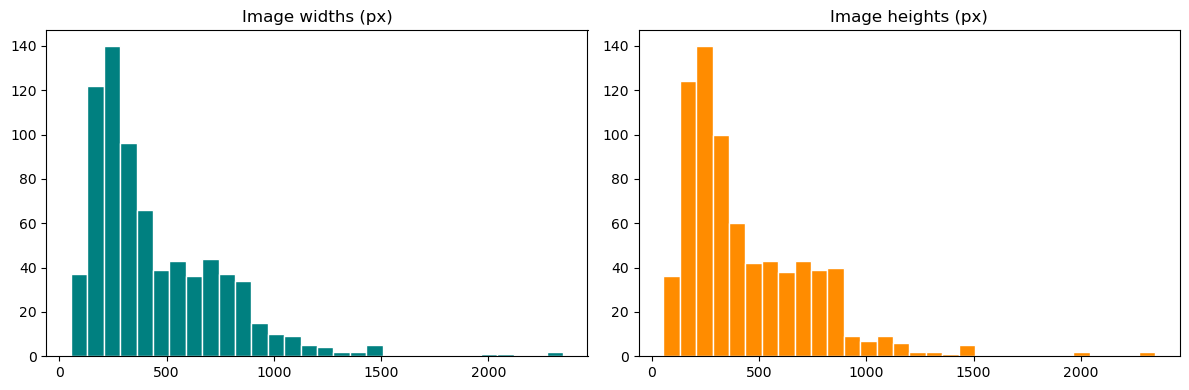

All images will be resized to 224x224 before training.


In [ ]:
# Image size analysis (sample 5 images per class)
sizes = []
for cls in class_names:
    imgs = list_images(DATA_DIR / cls)
    for p in random.sample(imgs, min(5, len(imgs))):
        with Image.open(p) as img:
            sizes.append(img.size)  # (width, height)

widths, heights = zip(*sizes)
print(f'Width  — mean: {np.mean(widths):.0f}  min: {min(widths)}  max: {max(widths)}')
print(f'Height — mean: {np.mean(heights):.0f}  min: {min(heights)}  max: {max(heights)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=30, color='teal',       edgecolor='white')
axes[0].set_title('Image widths (px)')
axes[1].hist(heights, bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Image heights (px)')
plt.tight_layout()
plt.show()

print('All images will be resized to 224x224 before training.')

---
## 2. Data Preparation

In [8]:
# Transforms — augmentation only for training
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

In [9]:
from collections import Counter

# Load dataset three times with different transforms to avoid data leakage
train_data = datasets.ImageFolder(DATA_DIR, transform=train_transforms)
val_data   = datasets.ImageFolder(DATA_DIR, transform=eval_transforms)
test_data  = datasets.ImageFolder(DATA_DIR, transform=eval_transforms)

n_total = len(train_data)
labels  = train_data.targets  # class index for every image

# Stratified split: 70% train / 15% val / 15% test
# Guarantees each of the 150 classes is proportionally represented in all three sets
train_idx, valtest_idx = train_test_split(
    range(n_total), test_size=0.30, stratify=labels, random_state=42
)
valtest_labels = [labels[i] for i in valtest_idx]
val_idx, test_idx = train_test_split(
    valtest_idx, test_size=0.50, stratify=valtest_labels, random_state=42
)

train_set = Subset(train_data, train_idx)
val_set   = Subset(val_data,   val_idx)
test_set  = Subset(test_data,  test_idx)

print(f'Train : {len(train_set):,} images')
print(f'Val   : {len(val_set):,} images')
print(f'Test  : {len(test_set):,} images')

# Verify stratification: every class should appear in val and test
val_counts  = Counter(labels[i] for i in val_idx)
test_counts = Counter(labels[i] for i in test_idx)
print(f'Val  — min / max samples per class: {min(val_counts.values())} / {max(val_counts.values())}')
print(f'Test — min / max samples per class: {min(test_counts.values())} / {max(test_counts.values())}')

Train : 4,774 images
Val   : 1,023 images
Test  : 1,023 images
Val  — min / max samples per class: 4 / 10
Test — min / max samples per class: 4 / 10


In [10]:
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Quick sanity check
imgs, labels = next(iter(train_loader))
print(f'Batch shape : {imgs.shape}  — expected [32, 3, 224, 224]')
print(f'Label range : {labels.min().item()} – {labels.max().item()}')

Batch shape : torch.Size([32, 3, 224, 224])  — expected [32, 3, 224, 224]
Label range : 7 – 146


---
## 3. Model Training

We use **EfficientNet-B0** pretrained on ImageNet and adapt the classifier head for 150 Pokémon classes.

Training has two phases:
- **Phase 1** — freeze the backbone and train only the new classifier head (5 epochs)
- **Phase 2** — unfreeze everything and fine-tune with a lower learning rate (up to 20 epochs, early stopping patience = 7)

In [11]:
model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model = model.to(DEVICE)

print(f'Classifier head: {model.classifier[1]}')
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable:,}')

Classifier head: Linear(in_features=1280, out_features=150, bias=True)
Trainable parameters: 4,199,698


In [12]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total

In [13]:
criterion = nn.CrossEntropyLoss()
history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

# ── Phase 1: Train classifier head only ──────────────────────────────────────
for param in model.features.parameters():
    param.requires_grad = False

optimizer = optim.Adam(model.classifier.parameters(), lr=LR_HEAD)

print('Phase 1 — Classifier head only')
for epoch in range(NUM_EPOCHS_HEAD):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), MODEL_PATH)
    print(f'  Epoch {epoch+1}/{NUM_EPOCHS_HEAD} | '
          f'train loss {tr_loss:.4f} acc {tr_acc:.3f} | '
          f'val loss {vl_loss:.4f} acc {vl_acc:.3f}')

Phase 1 — Classifier head only
  Epoch 1/5 | train loss 3.9240 acc 0.319 | val loss 2.9421 acc 0.601
  Epoch 2/5 | train loss 2.1474 acc 0.718 | val loss 2.0436 acc 0.685
  Epoch 3/5 | train loss 1.4311 acc 0.811 | val loss 1.6703 acc 0.727
  Epoch 4/5 | train loss 1.0931 acc 0.835 | val loss 1.4195 acc 0.754
  Epoch 5/5 | train loss 0.8895 acc 0.864 | val loss 1.3237 acc 0.747


In [14]:
# ── Phase 2: Fine-tune all layers ─────────────────────────────────────────────
for param in model.features.parameters():
    param.requires_grad = True

optimizer        = optim.Adam(model.parameters(), lr=LR_FULL)
scheduler        = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS_FULL)
patience_counter = 0

print(f'Phase 2 — Full fine-tuning  (early stopping patience={PATIENCE})')
for epoch in range(NUM_EPOCHS_FULL):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc = evaluate(model, val_loader, criterion)
    scheduler.step()
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc     = vl_acc
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_PATH)
        tag = '  ← best'
    else:
        patience_counter += 1
        tag = f'  (no improve {patience_counter}/{PATIENCE})'

    print(f'  Epoch {epoch+1:2d}/{NUM_EPOCHS_FULL} | '
          f'train loss {tr_loss:.4f} acc {tr_acc:.3f} | '
          f'val loss {vl_loss:.4f} acc {vl_acc:.3f}{tag}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping triggered — no improvement for {PATIENCE} epochs.')
        break

print(f'\nBest val accuracy: {best_val_acc:.4f}')

Phase 2 — Full fine-tuning  (early stopping patience=7)
  Epoch  1/20 | train loss 0.3817 acc 0.933 | val loss 0.4338 acc 0.894  ← best
  Epoch  2/20 | train loss 0.1674 acc 0.970 | val loss 0.3503 acc 0.909  ← best
  Epoch  3/20 | train loss 0.1044 acc 0.984 | val loss 0.3041 acc 0.919  ← best
  Epoch  4/20 | train loss 0.0752 acc 0.989 | val loss 0.2707 acc 0.930  ← best
  Epoch  5/20 | train loss 0.0574 acc 0.992 | val loss 0.2482 acc 0.938  ← best
  Epoch  6/20 | train loss 0.0491 acc 0.992 | val loss 0.2401 acc 0.939  ← best
  Epoch  7/20 | train loss 0.0393 acc 0.994 | val loss 0.2316 acc 0.937  (no improve 1/7)
  Epoch  8/20 | train loss 0.0313 acc 0.996 | val loss 0.2351 acc 0.939  (no improve 2/7)
  Epoch  9/20 | train loss 0.0295 acc 0.996 | val loss 0.2259 acc 0.939  (no improve 3/7)
  Epoch 10/20 | train loss 0.0281 acc 0.995 | val loss 0.2195 acc 0.942  ← best
  Epoch 11/20 | train loss 0.0245 acc 0.997 | val loss 0.2174 acc 0.947  ← best
  Epoch 12/20 | train loss 0.0202 

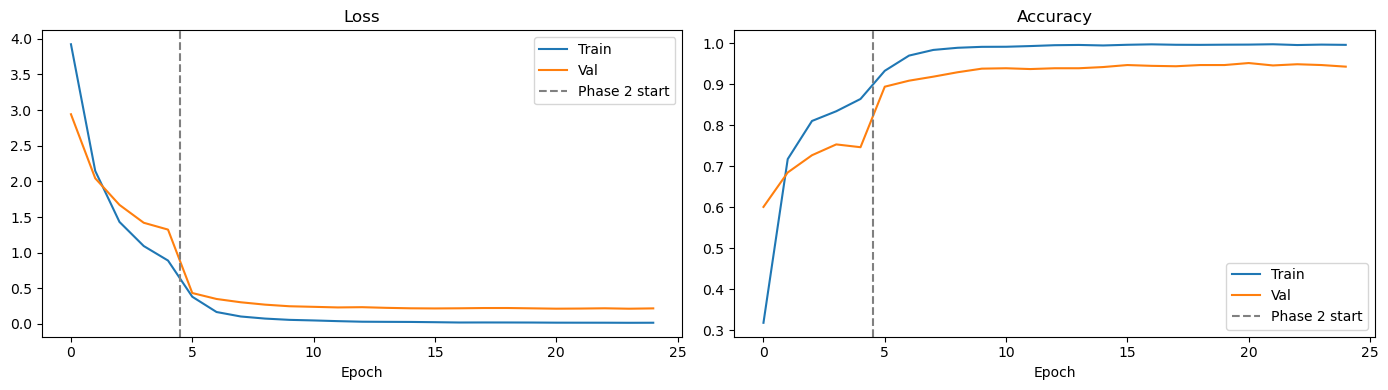

In [ ]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
phase_boundary = NUM_EPOCHS_HEAD - 0.5

for ax, metric, title in zip(axes, [('train_loss','val_loss'), ('train_acc','val_acc')],
                              ['Loss', 'Accuracy']):
    ax.plot(history[metric[0]], label='Train')
    ax.plot(history[metric[1]], label='Val')
    ax.axvline(phase_boundary, color='gray', linestyle='--', label='Phase 2 start')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()

plt.tight_layout()
plt.show()

---
## 4. Evaluation

In [16]:
# Load best checkpoint
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

_, test_acc = evaluate(model, test_loader, criterion)
print(f'Top-1 accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

@torch.no_grad()
def top5_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        top5 = model(imgs).topk(5, dim=1).indices
        correct += (top5 == labels.unsqueeze(1)).any(dim=1).sum().item()
        total   += imgs.size(0)
    return correct / total

top5 = top5_accuracy(model, test_loader)
print(f'Top-5 accuracy: {top5:.4f} ({top5*100:.2f}%)')

Top-1 accuracy: 0.9404 (94.04%)
Top-5 accuracy: 0.9922 (99.22%)


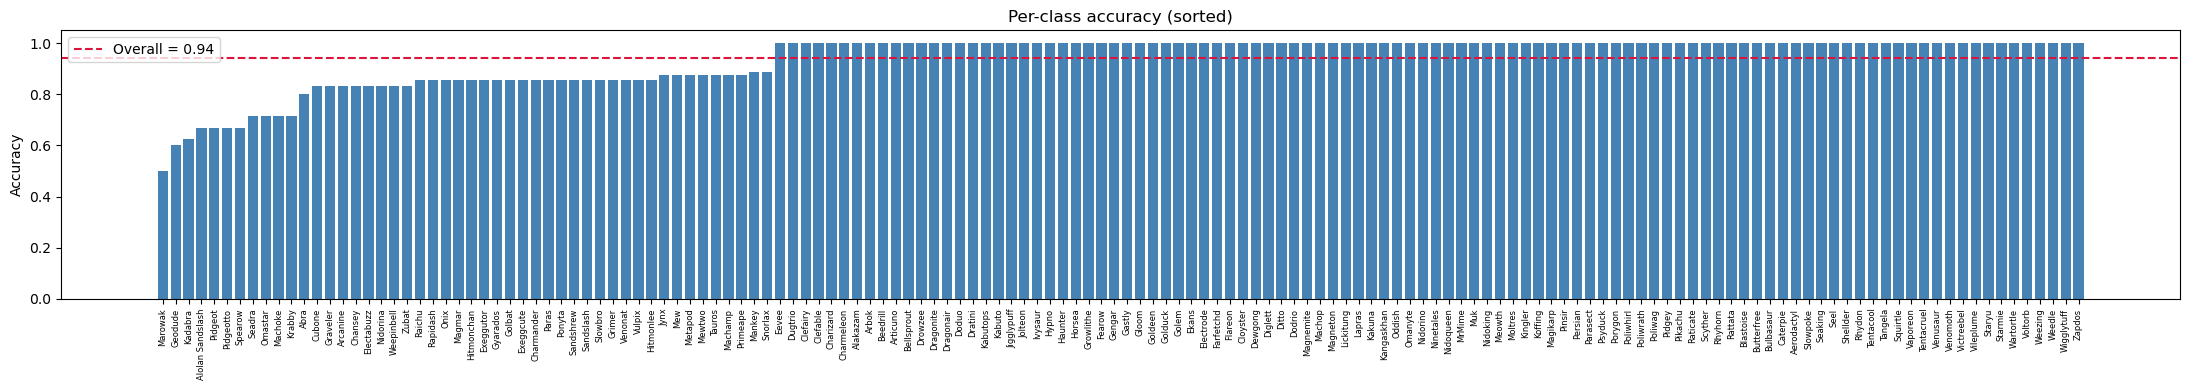

5 hardest classes:
  Marowak                   0.50
  Geodude                   0.60
  Kadabra                   0.62
  Alolan Sandslash          0.67
  Pidgeot                   0.67


In [17]:
# Per-class accuracy
@torch.no_grad()
def per_class_accuracy(model, loader):
    model.eval()
    correct = torch.zeros(NUM_CLASSES)
    total   = torch.zeros(NUM_CLASSES)
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        preds = model(imgs).argmax(1)
        for c in range(NUM_CLASSES):
            mask = labels == c
            correct[c] += (preds[mask] == c).sum().item()
            total[c]   += mask.sum().item()
    return (correct / total.clamp(min=1)).numpy()

class_acc  = per_class_accuracy(model, test_loader)
sorted_idx = np.argsort(class_acc)

fig, ax = plt.subplots(figsize=(22, 4))
ax.bar(range(NUM_CLASSES), class_acc[sorted_idx], color='steelblue')
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels([class_names[i] for i in sorted_idx], rotation=90, fontsize=6)
ax.axhline(test_acc, color='crimson', linestyle='--', label=f'Overall = {test_acc:.2f}')
ax.set_title('Per-class accuracy (sorted)')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()

print('5 hardest classes:')
for i in sorted_idx[:5]:
    print(f'  {class_names[i]:25s} {class_acc[i]:.2f}')

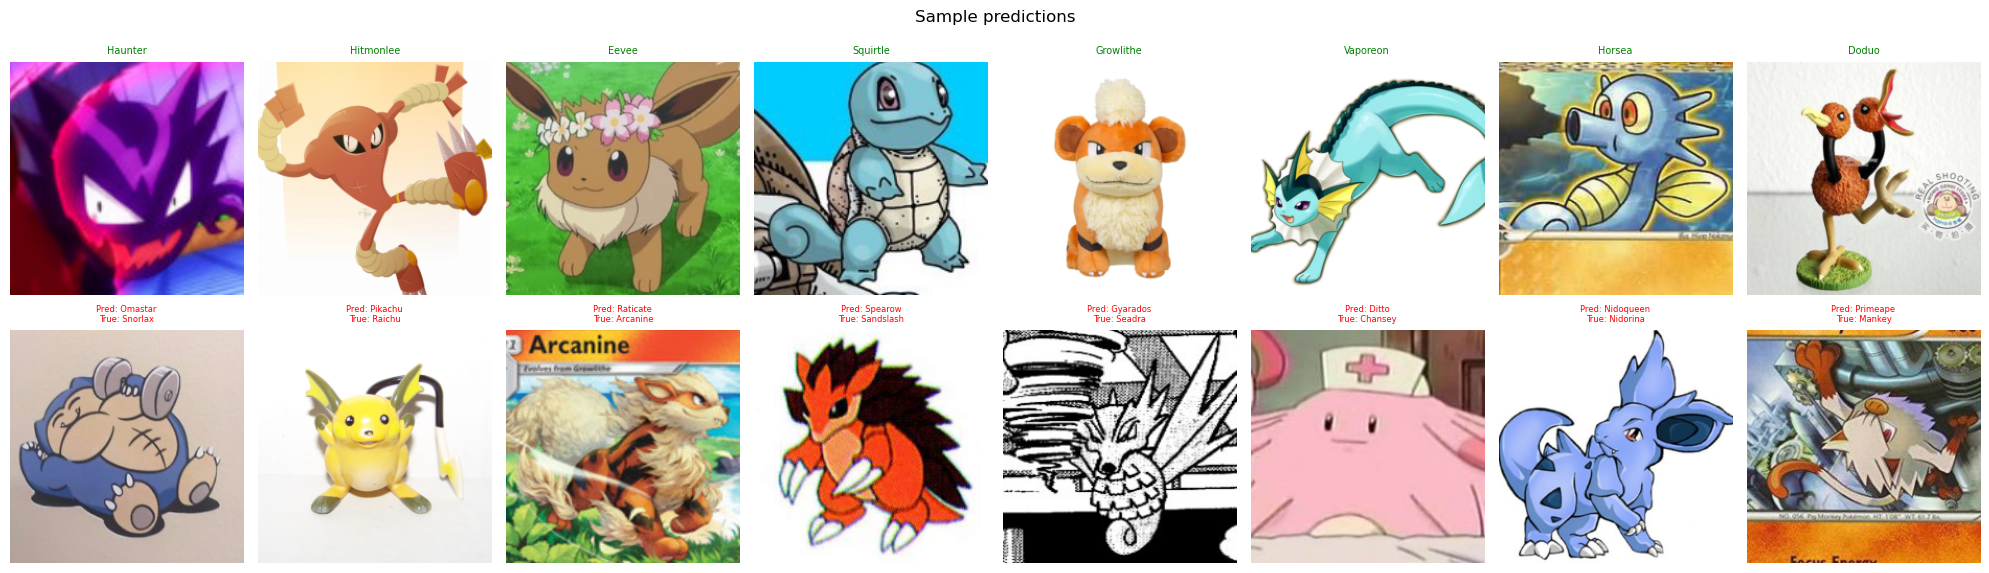

In [ ]:
# Sample correct and incorrect predictions
@torch.no_grad()
def collect_predictions(model, loader, max_batches=6):
    model.eval()
    all_imgs, all_preds, all_labels = [], [], []
    for i, (imgs, labels) in enumerate(loader):
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_imgs.append(imgs)
        all_preds.append(preds)
        all_labels.append(labels)
        if i + 1 >= max_batches:
            break
    return torch.cat(all_imgs), torch.cat(all_preds), torch.cat(all_labels)

imgs_t, preds_t, labels_t = collect_predictions(model, test_loader)

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
denorm = lambda t: (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

correct_idx   = (preds_t == labels_t).nonzero(as_tuple=True)[0][:8]
incorrect_idx = (preds_t != labels_t).nonzero(as_tuple=True)[0][:8]

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for ax, i in zip(axes[0], correct_idx):
    ax.imshow(denorm(imgs_t[i]))
    ax.set_title(class_names[preds_t[i]], fontsize=7, color='green')
    ax.axis('off')
for ax, i in zip(axes[1], incorrect_idx):
    ax.imshow(denorm(imgs_t[i]))
    ax.set_title(f'Pred: {class_names[preds_t[i]]}\nTrue: {class_names[labels_t[i]]}',
                 fontsize=6, color='red')
    ax.axis('off')

axes[0][0].set_ylabel('Correct', fontsize=10)
axes[1][0].set_ylabel('Incorrect', fontsize=10)
plt.suptitle('Sample predictions', fontsize=12)
plt.tight_layout()
plt.show()

Top 10 most confused pairs (true → predicted):
  2x  Pidgeot                → Pidgeotto
  2x  Machoke                → Machamp
  2x  Kadabra                → Alakazam
  1x  Zubat                  → Golbat
  1x  Weepinbell             → Metapod
  1x  Vulpix                 → Eevee
  1x  Venonat                → Magmar
  1x  Tauros                 → Paras
  1x  Spearow                → Pidgeotto
  1x  Spearow                → Pidgeot


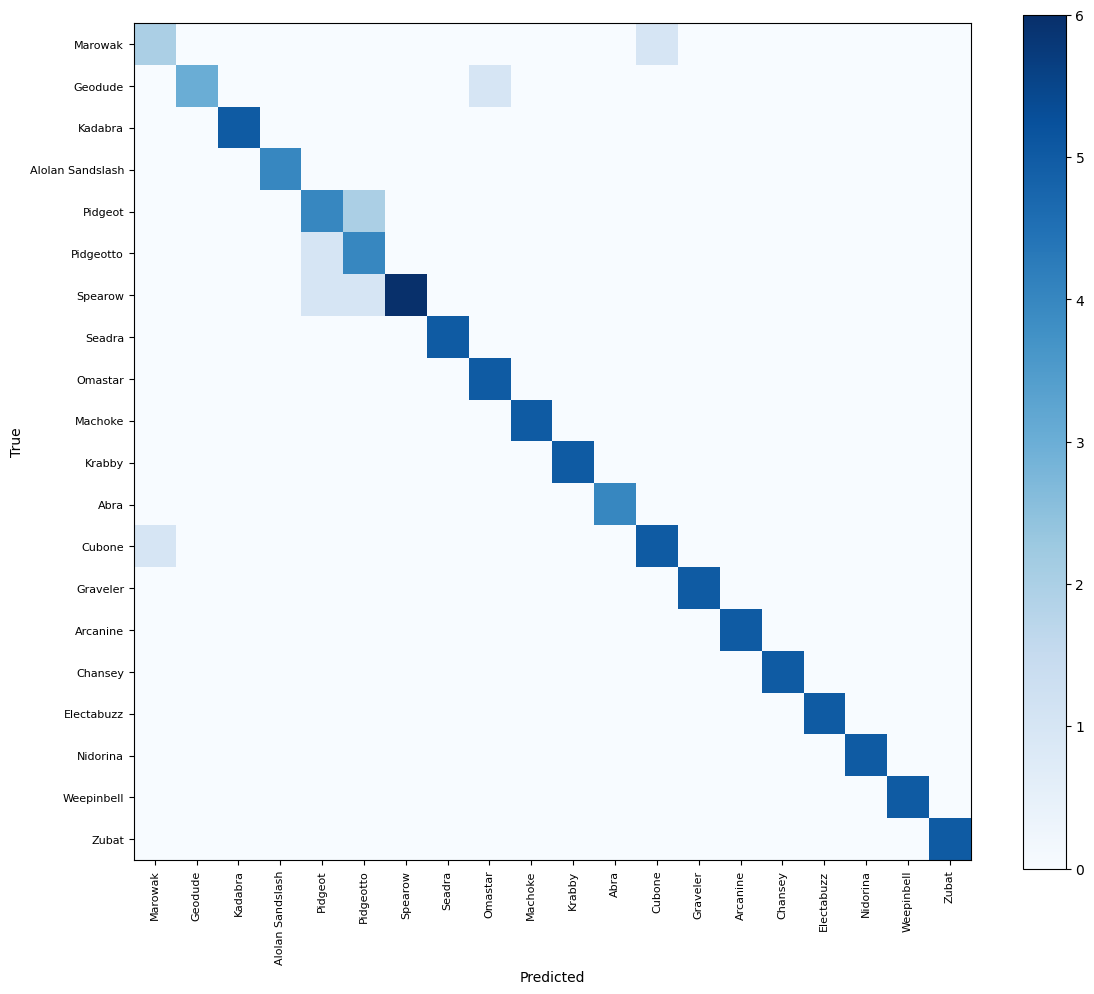

In [19]:
from sklearn.metrics import confusion_matrix

# Load best checkpoint (safe to run without retraining)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

# Collect full test set predictions
@torch.no_grad()
def get_all_predictions(model, loader):
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        preds = model(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)
    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()

all_preds, all_labels = get_all_predictions(model, test_loader)
cm_full = confusion_matrix(all_labels, all_preds)

# Top 10 confused pairs (off-diagonal only)
cm_nodiag = cm_full.copy()
np.fill_diagonal(cm_nodiag, 0)
confused_pairs = [
    (cm_nodiag[i, j], class_names[i], class_names[j])
    for i in range(NUM_CLASSES)
    for j in range(NUM_CLASSES)
    if cm_nodiag[i, j] > 0
]
print('Top 10 most confused pairs (true → predicted):')
for count, true_cls, pred_cls in sorted(confused_pairs, reverse=True)[:10]:
    print(f'  {count}x  {true_cls:22s} → {pred_cls}')

# Compute per-class accuracy to find the 20 hardest classes
class_correct = np.zeros(NUM_CLASSES)
class_total   = np.zeros(NUM_CLASSES)
for pred, label in zip(all_preds, all_labels):
    class_total[label]   += 1
    class_correct[label] += (pred == label)
class_acc_cm = class_correct / np.maximum(class_total, 1)
hard_idx     = np.argsort(class_acc_cm)[:20]

# Heatmap focused on the 20 hardest classes
focus_cm    = cm_full[np.ix_(hard_idx, hard_idx)]
focus_names = [class_names[i] for i in hard_idx]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(focus_cm, cmap='Blues')
ax.set_xticks(range(20))
ax.set_yticks(range(20))
ax.set_xticklabels(focus_names, rotation=90, fontsize=8)
ax.set_yticklabels(focus_names, fontsize=8)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

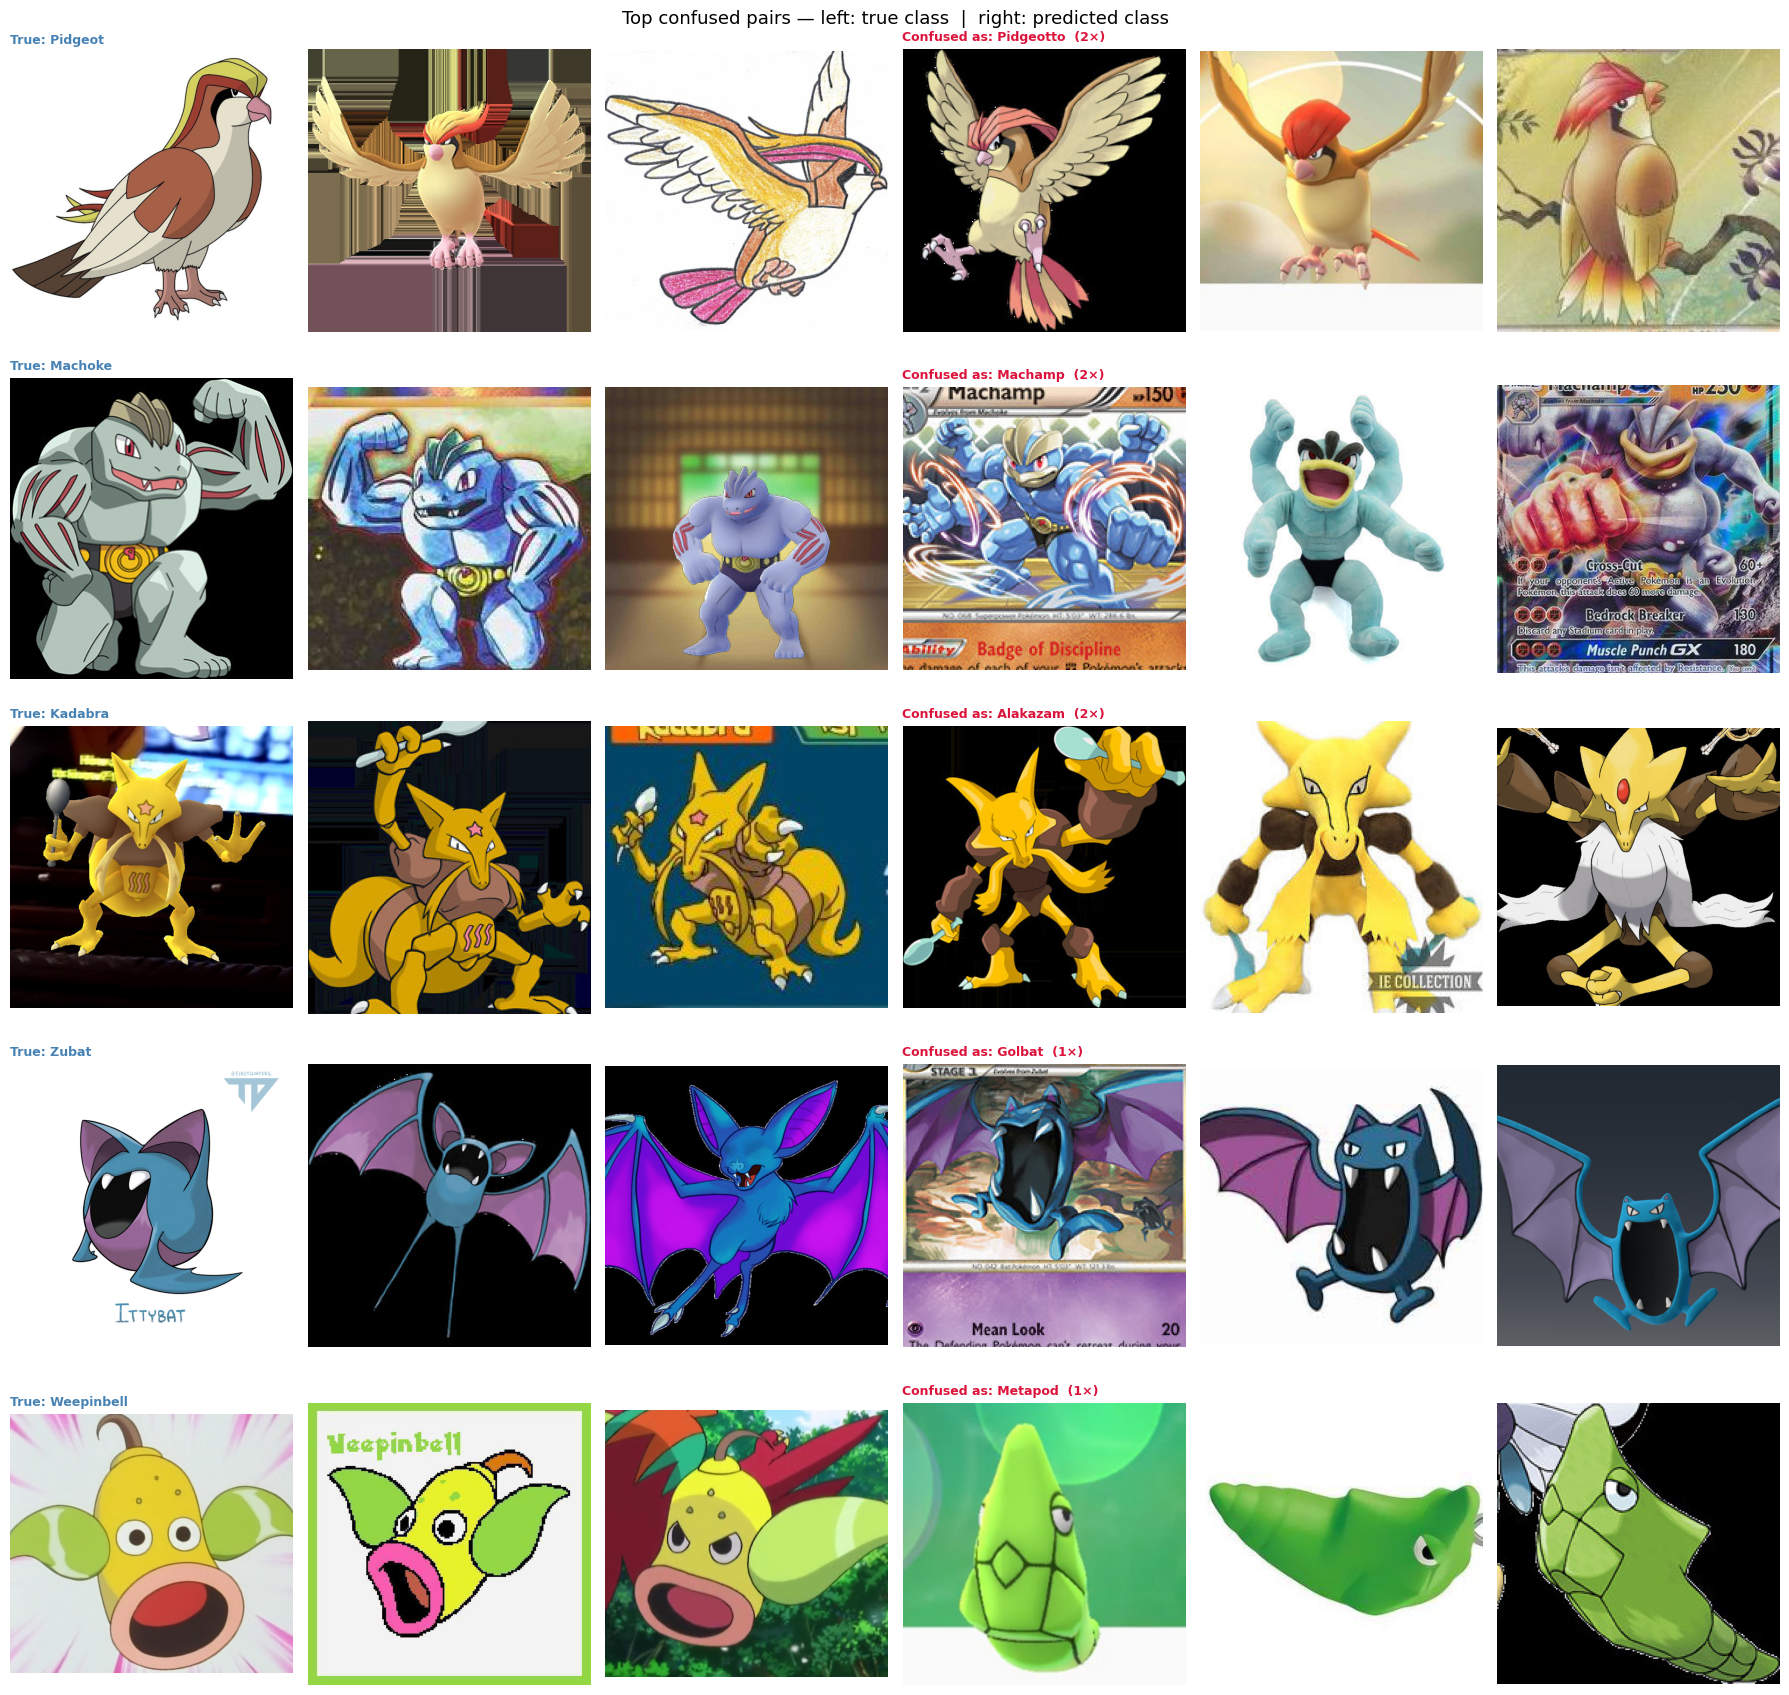

In [20]:
# Visualize the most confused pairs side by side
# Shows WHY the model mixes them up — typically visual similarity (same species family, similar shape/color)
# Depends on: confused_pairs computed in the cell above
N_PAIRS   = 5
N_SAMPLES = 3
top_pairs = sorted(confused_pairs, reverse=True)[:N_PAIRS]

fig, axes = plt.subplots(N_PAIRS, N_SAMPLES * 2, figsize=(18, 3.5 * N_PAIRS))

for row, (count, true_cls, pred_cls) in enumerate(top_pairs):
    true_imgs = random.sample(list_images(DATA_DIR / true_cls), N_SAMPLES)
    pred_imgs = random.sample(list_images(DATA_DIR / pred_cls), N_SAMPLES)

    for col, img_path in enumerate(true_imgs):
        ax = axes[row, col]
        ax.imshow(Image.open(img_path).convert('RGB'))
        ax.axis('off')

    for col, img_path in enumerate(pred_imgs):
        ax = axes[row, col + N_SAMPLES]
        ax.imshow(Image.open(img_path).convert('RGB'))
        ax.axis('off')

    axes[row, 0].set_title(
        f'True: {true_cls}', fontsize=9, color='steelblue', fontweight='bold', loc='left'
    )
    axes[row, N_SAMPLES].set_title(
        f'Confused as: {pred_cls}  ({count}×)', fontsize=9, color='crimson', fontweight='bold', loc='left'
    )

plt.suptitle('Top confused pairs — left: true class  |  right: predicted class', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Team Recommendation

Given a team of 5 Pokémon (identified by the classifier), we recommend the best 6th member.

**Strategy (v1 — type coverage):** maximize the number of unique types in the full team of 6.  
The more type diversity, the fewer blind spots the team has against opponents.

In [21]:
# Type mapping for all 150 Pokemon in the dataset
POKEMON_TYPES = {
    'Abra': ['Psychic'],
    'Aerodactyl': ['Rock', 'Flying'],
    'Alakazam': ['Psychic'],
    'Alolan Sandslash': ['Ice', 'Steel'],
    'Arbok': ['Poison'],
    'Arcanine': ['Fire'],
    'Articuno': ['Ice', 'Flying'],
    'Beedrill': ['Bug', 'Poison'],
    'Bellsprout': ['Grass', 'Poison'],
    'Blastoise': ['Water'],
    'Bulbasaur': ['Grass', 'Poison'],
    'Butterfree': ['Bug', 'Flying'],
    'Caterpie': ['Bug'],
    'Chansey': ['Normal'],
    'Charizard': ['Fire', 'Flying'],
    'Charmander': ['Fire'],
    'Charmeleon': ['Fire'],
    'Clefable': ['Fairy'],
    'Clefairy': ['Fairy'],
    'Cloyster': ['Water', 'Ice'],
    'Cubone': ['Ground'],
    'Dewgong': ['Water', 'Ice'],
    'Diglett': ['Ground'],
    'Ditto': ['Normal'],
    'Dodrio': ['Normal', 'Flying'],
    'Doduo': ['Normal', 'Flying'],
    'Dragonair': ['Dragon'],
    'Dragonite': ['Dragon', 'Flying'],
    'Dratini': ['Dragon'],
    'Drowzee': ['Psychic'],
    'Dugtrio': ['Ground'],
    'Eevee': ['Normal'],
    'Ekans': ['Poison'],
    'Electabuzz': ['Electric'],
    'Electrode': ['Electric'],
    'Exeggcute': ['Grass', 'Psychic'],
    'Exeggutor': ['Grass', 'Psychic'],
    'Farfetchd': ['Normal', 'Flying'],
    'Fearow': ['Normal', 'Flying'],
    'Flareon': ['Fire'],
    'Gastly': ['Ghost', 'Poison'],
    'Gengar': ['Ghost', 'Poison'],
    'Geodude': ['Rock', 'Ground'],
    'Gloom': ['Grass', 'Poison'],
    'Golbat': ['Poison', 'Flying'],
    'Goldeen': ['Water'],
    'Golduck': ['Water'],
    'Golem': ['Rock', 'Ground'],
    'Graveler': ['Rock', 'Ground'],
    'Grimer': ['Poison'],
    'Growlithe': ['Fire'],
    'Gyarados': ['Water', 'Flying'],
    'Haunter': ['Ghost', 'Poison'],
    'Hitmonchan': ['Fighting'],
    'Hitmonlee': ['Fighting'],
    'Horsea': ['Water'],
    'Hypno': ['Psychic'],
    'Ivysaur': ['Grass', 'Poison'],
    'Jigglypuff': ['Normal', 'Fairy'],
    'Jolteon': ['Electric'],
    'Jynx': ['Ice', 'Psychic'],
    'Kabuto': ['Rock', 'Water'],
    'Kabutops': ['Rock', 'Water'],
    'Kadabra': ['Psychic'],
    'Kakuna': ['Bug', 'Poison'],
    'Kangaskhan': ['Normal'],
    'Kingler': ['Water'],
    'Koffing': ['Poison'],
    'Krabby': ['Water'],
    'Lapras': ['Water', 'Ice'],
    'Lickitung': ['Normal'],
    'Machamp': ['Fighting'],
    'Machoke': ['Fighting'],
    'Machop': ['Fighting'],
    'Magikarp': ['Water'],
    'Magmar': ['Fire'],
    'Magnemite': ['Electric', 'Steel'],
    'Magneton': ['Electric', 'Steel'],
    'Mankey': ['Fighting'],
    'Marowak': ['Ground'],
    'Meowth': ['Normal'],
    'Metapod': ['Bug'],
    'Mew': ['Psychic'],
    'Mewtwo': ['Psychic'],
    'Moltres': ['Fire', 'Flying'],
    'MrMime': ['Psychic', 'Fairy'],
    'Muk': ['Poison'],
    'Nidoking': ['Poison', 'Ground'],
    'Nidoqueen': ['Poison', 'Ground'],
    'Nidorina': ['Poison'],
    'Nidorino': ['Poison'],
    'Ninetales': ['Fire'],
    'Oddish': ['Grass', 'Poison'],
    'Omanyte': ['Rock', 'Water'],
    'Omastar': ['Rock', 'Water'],
    'Onix': ['Rock', 'Ground'],
    'Paras': ['Bug', 'Grass'],
    'Parasect': ['Bug', 'Grass'],
    'Persian': ['Normal'],
    'Pidgeot': ['Normal', 'Flying'],
    'Pidgeotto': ['Normal', 'Flying'],
    'Pidgey': ['Normal', 'Flying'],
    'Pikachu': ['Electric'],
    'Pinsir': ['Bug'],
    'Poliwag': ['Water'],
    'Poliwhirl': ['Water'],
    'Poliwrath': ['Water', 'Fighting'],
    'Ponyta': ['Fire'],
    'Porygon': ['Normal'],
    'Primeape': ['Fighting'],
    'Psyduck': ['Water'],
    'Raichu': ['Electric'],
    'Rapidash': ['Fire'],
    'Raticate': ['Normal'],
    'Rattata': ['Normal'],
    'Rhydon': ['Ground', 'Rock'],
    'Rhyhorn': ['Ground', 'Rock'],
    'Sandshrew': ['Ground'],
    'Sandslash': ['Ground'],
    'Scyther': ['Bug', 'Flying'],
    'Seadra': ['Water'],
    'Seaking': ['Water'],
    'Seel': ['Water'],
    'Shellder': ['Water'],
    'Slowbro': ['Water', 'Psychic'],
    'Slowpoke': ['Water', 'Psychic'],
    'Snorlax': ['Normal'],
    'Spearow': ['Normal', 'Flying'],
    'Squirtle': ['Water'],
    'Starmie': ['Water', 'Psychic'],
    'Staryu': ['Water'],
    'Tangela': ['Grass'],
    'Tauros': ['Normal'],
    'Tentacool': ['Water', 'Poison'],
    'Tentacruel': ['Water', 'Poison'],
    'Vaporeon': ['Water'],
    'Venomoth': ['Bug', 'Poison'],
    'Venonat': ['Bug', 'Poison'],
    'Venusaur': ['Grass', 'Poison'],
    'Victreebel': ['Grass', 'Poison'],
    'Vileplume': ['Grass', 'Poison'],
    'Voltorb': ['Electric'],
    'Vulpix': ['Fire'],
    'Wartortle': ['Water'],
    'Weedle': ['Bug', 'Poison'],
    'Weepinbell': ['Grass', 'Poison'],
    'Weezing': ['Poison'],
    'Wigglytuff': ['Normal', 'Fairy'],
    'Zapdos': ['Electric', 'Flying'],
    'Zubat': ['Poison', 'Flying'],
}

In [22]:
def recommend_sixth(team_of_5, top_n=5):
    """
    Recommend the best 6th Pokemon to complete a team of 5.
    Scoring: number of new unique types the candidate adds to the team.
    """
    assert len(team_of_5) == 5, 'Team must have exactly 5 Pokemon.'

    team_types = set()
    for pokemon in team_of_5:
        team_types.update(POKEMON_TYPES.get(pokemon, []))

    scores = {}
    for pokemon, types in POKEMON_TYPES.items():
        if pokemon in team_of_5:
            continue
        scores[pokemon] = len(set(types) - team_types)

    ranked = sorted(scores.items(), key=lambda x: (-x[1], x[0]))

    print(f'Team         : {team_of_5}')
    print(f'Types covered: {sorted(team_types)}')
    print(f'\nTop {top_n} recommendations for the 6th slot:')
    for rank, (pokemon, score) in enumerate(ranked[:top_n], 1):
        new_types = sorted(set(POKEMON_TYPES[pokemon]) - team_types)
        print(f'  {rank}. {pokemon:22s} adds {score} new type(s): {new_types}')

    return [p for p, _ in ranked[:top_n]]

In [23]:
def classify_image(img_path, model, transform):
    """Run inference on one image and return the predicted Pokemon name."""
    model.eval()
    img    = Image.open(img_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs   = torch.softmax(model(tensor), dim=1)[0]
        top5p, top5i = probs.topk(5)
    print(f'Image: {Path(img_path).name}')
    for p, i in zip(top5p, top5i):
        print(f'  {idx_to_class[i.item()]:22s} {p.item()*100:.1f}%')
    return idx_to_class[top5i[0].item()]

In [24]:
# ── Demo ──────────────────────────────────────────────────────────────────────
# Pick 5 random Pokemon and classify one image from each
demo_pokemon = random.sample(class_names, 5)
demo_paths   = [random.choice(list_images(DATA_DIR / p)) for p in demo_pokemon]

print('=== Classifying 5 Pokemon images ===')
predicted_team = []
for path in demo_paths:
    name = classify_image(path, model, eval_transforms)
    predicted_team.append(name)
    print()

print('\n=== Recommendation ===')
top_picks = recommend_sixth(predicted_team)

=== Classifying 5 Pokemon images ===
Image: fda5fbb661fb43ef9b9a876389e0e1fc.jpg
  Jigglypuff             100.0%
  Clefairy               0.0%
  Wigglytuff             0.0%
  Poliwag                0.0%
  Clefable               0.0%

Image: aa9b85417f4f43dab9f125484e0621b9.jpg
  Oddish                 99.9%
  Arbok                  0.0%
  Ivysaur                0.0%
  Gengar                 0.0%
  Vileplume              0.0%

Image: 3c9be35564a3460dae952e2579569fb4.jpg
  Goldeen                99.8%
  Seaking                0.1%
  Clefable               0.0%
  MrMime                 0.0%
  Wigglytuff             0.0%

Image: 88ccc817d5004328806a888db562f531.jpg
  Magneton               99.8%
  Magnemite              0.1%
  Exeggcute              0.0%
  Machoke                0.0%
  Poliwhirl              0.0%

Image: 1fc0f99cc95240138620f2b8a1ba86ec.jpg
  Alolan Sandslash       100.0%
  Golduck                0.0%
  Articuno               0.0%
  Seadra                 0.0%
  Kabutops  

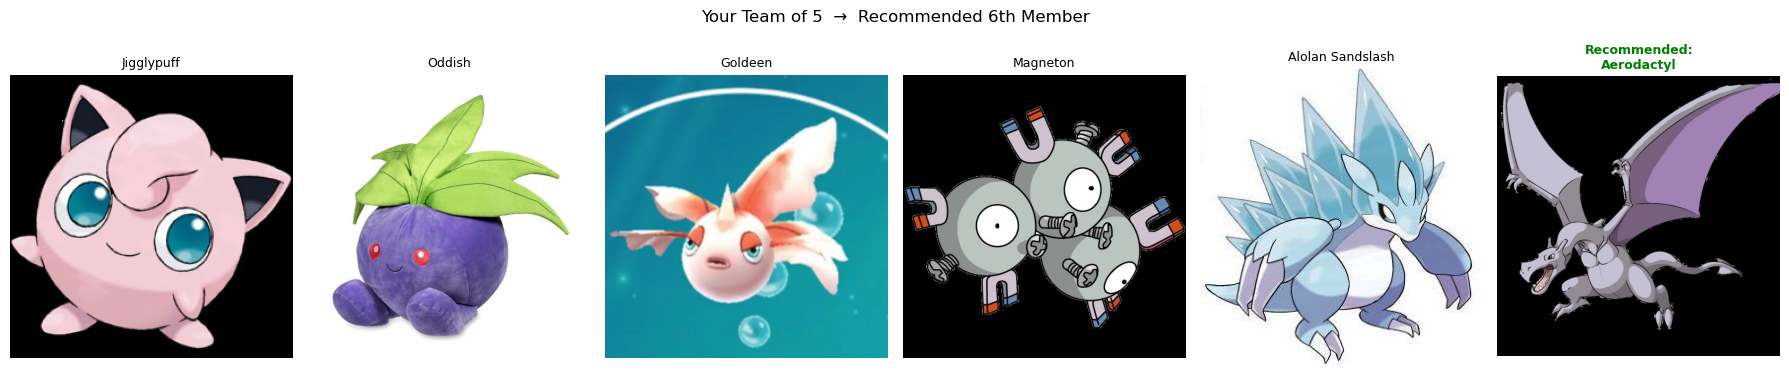

In [25]:
# Visualize team + recommendation
fig, axes = plt.subplots(1, 6, figsize=(18, 4))

for ax, path, name in zip(axes[:5], demo_paths, predicted_team):
    ax.imshow(Image.open(path).convert('RGB'))
    ax.set_title(name, fontsize=9)
    ax.axis('off')

rec_name = top_picks[0]
rec_img  = random.choice(list_images(DATA_DIR / rec_name))
axes[5].imshow(Image.open(rec_img).convert('RGB'))
axes[5].set_title(f'Recommended:\n{rec_name}', fontsize=9, color='green', fontweight='bold')
axes[5].axis('off')
for spine in axes[5].spines.values():
    spine.set_edgecolor('green')
    spine.set_linewidth(3)

plt.suptitle('Your Team of 5  →  Recommended 6th Member', fontsize=12)
plt.tight_layout()
plt.show()